In [ ]:
# Starter imports

import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

# Import Data

from pybaseball import statcast 

**Research Question**: How can pitch-level characteristics and in-game context at the moment of pitch release be used to predict whether a batter will swing or take a pitch in MLB games?

**The statcast dataset has over a million rows, so we will have this dataset filtered to the June of the 2024 MLB Season!**

In [29]:
june_statcast_2024 = pd.read_csv("june_statcast_2024.csv")

june_statcast_2024.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,ST,2024-06-30,82.4,-3.63,4.42,"Sewald, Paul",680869,623149,strikeout,called_strike,...,2.0,2.68,-1.28,-1.28,15.8,NaN,NaN,NaN,NaN,NaN
1,ST,2024-06-30,82.2,-3.70,4.35,"Sewald, Paul",680869,623149,NaN,foul,...,2.0,2.78,-1.26,-1.26,16.6,19.691472,-13.003297,35.999290,42.538496,37.741756
2,FF,2024-06-30,90.8,-3.55,4.54,"Sewald, Paul",680869,623149,NaN,foul,...,2.0,1.50,0.81,0.81,16.6,14.876329,3.342341,30.357166,37.709934,27.167091
3,ST,2024-06-30,83.4,-3.64,4.40,"Sewald, Paul",680869,623149,NaN,ball,...,2.0,2.49,-1.45,-1.45,15.3,NaN,NaN,NaN,NaN,NaN
4,FF,2024-06-30,89.9,-3.53,4.45,"Sewald, Paul",680869,623149,NaN,foul,...,2.0,1.86,0.68,0.68,19.2,10.061360,12.153604,30.257349,43.514080,22.018539


**Let's start with some basic statistics on our dataset.**

In [26]:
june_statcast_2024.describe()

,release_speed,release_pos_x,release_pos_z,batter,pitcher,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
count,115953.000000,115953.000000,115953.000000,116355.000000,116355.000000,0.0,0.0,0.0,0.0,115939.000000,...,116012.000000,115948.000000,115953.000000,115953.000000,114963.000000,53570.000000,53570.000000,53569.000000,53525.000000,53525.000000
mean,89.255297,-0.804447,5.757763,640943.322247,638099.830158,NaN,NaN,NaN,NaN,9.024108,...,1.712943,2.319999,0.324320,-0.107056,38.117908,9.255037,-0.854756,32.227414,37.099818,29.875902
std,6.024125,1.881957,0.527013,51393.908377,53600.189628,NaN,NaN,NaN,NaN,4.238485,...,3.796852,1.060860,0.834605,0.888982,12.929079,11.734485,20.370954,7.121973,7.242480,11.519003
min,31.900000,-4.680000,0.900000,444482.000000,434378.000000,NaN,NaN,NaN,NaN,1.000000,...,0.000000,0.270000,-2.200000,-2.200000,-70.100000,-88.324284,-179.136062,0.716620,8.911645,-11.977734
25%,84.900000,-2.120000,5.480000,621439.000000,607625.000000,NaN,NaN,NaN,NaN,5.000000,...,1.000000,1.400000,-0.320000,-0.860000,30.700000,2.045458,-12.944849,27.604088,32.130369,22.065354
50%,90.300000,-1.510000,5.800000,663728.000000,657508.000000,NaN,NaN,NaN,NaN,11.000000,...,1.000000,2.220000,0.500000,-0.210000,39.300000,9.597252,-0.071518,32.255026,37.080719,29.175451
75%,94.100000,0.920000,6.080000,671732.000000,671106.000000,NaN,NaN,NaN,NaN,13.000000,...,2.000000,2.990000,1.030000,0.640000,46.300000,17.004246,12.049693,36.893366,42.050658,37.357799
max,104.000000,4.550000,7.520000,807799.000000,814005.000000,NaN,NaN,NaN,NaN,14.000000,...,111.000000,24.050000,1.970000,2.090000,82.300000,80.892151,179.449388,88.124009,70.730504,71.731541


In [28]:
june_statcast_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116355 entries, 0 to 116354
Columns: 118 entries, pitch_type to intercept_ball_minus_batter_pos_y_inches
dtypes: float64(67), int64(34), object(17)
memory usage: 104.8+ MB


For our research problem, we want to create a target variable that represents what we are trying to predict. We wnat to know whether the batter will swing or not! The column `type` tells us what happened on the pitch and "S" indicates a swing, so we convert this into a binary variable where: `1 = swing` & `0 = take (ball)`!

In [42]:
june_statcast_2024["y_swing"] = (june_statcast_2024["type"] == "S").astype(int)
june_statcast_2024["y_swing"]

0         1
1         1
2         1
3         0
4         1
         ..
116350    1
116351    0
116352    0
116353    0
116354    0
Name: y_swing, Length: 116355, dtype: int64

Let's check how many swings & takes (balls) that we have in the dataset. We'll now calculate the proportions, which helps us understand whether the data is balanced or skewed! The dataset is fairly balanced, as both classes occur as similar rates. This is good bcause it makes the prediction task more reliable!

In [43]:
june_statcast_2024["y_swing"].value_counts(normalize=True)

y_swing
0    0.533522
1    0.466478
Name: proportion, dtype: float64

An interesting to explore is the swing behavior count. This is important because we want to see how the game situation affects a batter's decision!

In [46]:
june_statcast_2024.groupby(["balls", "strikes"])["y_swing"].mean().unstack()

strikes,0,1,2
balls,,,
0,0.509681,0.425856,0.375932
1,0.503705,0.454133,0.405144
2,0.528468,0.482793,0.449818
3,0.587971,0.497713,0.483402


Through this exploration, swing probability varies significantly with count, increasing with the number of balls and decreasing with the number of strikes, indicating that in-game context does play a role in the batter's decision making.

Let's now analyze pitch location!

For someone that is not into baseball as much, the plate_x represents how far the pitch is from the center of home plate horizontally. A value of 0 means that the pitch crossed the exact middle of the plate, negative values are inside to a right-handed batter, and positive values are outside. On the other hand, plate_z represents the height of the pitch as it crosses the plate, measured in feet from the ground. The strike zone is typically 1.5 to 3.5 feet high, depending on the batter, so values in that range are "hittable" pitches.

In [48]:
june_statcast_2024[["plate_x", "plate_z"]].describe()

,plate_x,plate_z
count,115939.000000,115939.000000
mean,0.059699,2.313788
std,0.842836,0.963568
min,-5.363822,-3.076603
25%,-0.504071,1.686449
50%,0.057319,2.318570
75%,0.620964,2.949802
max,4.888425,12.358563


This describes whre pitches are located across the plate. On average, pitches are centered horizontally (w/ a mean `plate_x` = 0.06) and around mid-height in the strike zone (mean `plate_z` = 2.31), which is expected since most pitches are thrown nar the zone. The spread (standard deviation) shows that there is meaningful variation, meaning batter wil see pitches both inside and outside the strike zone. The minimum and maximum values indicate some extreme pitches far outside the zone, which are important for understanding when batters choose not to swing.

Let's now take a sample of our data to plot the strike zone!

In [54]:
sample = june_statcast_2024.sample(5000, random_state=42)

The swings (orange) are heavily concentrated around the middle of the strike zone, especially near the center of the plate where pitches are easiest to hit. Most pitches fall roughly between about -1.5 and 1.5, which corresponds to the width of the strike zone and just beyond it. Takes are more spread out and dominate the edges of th zone and outside areas where pitches are harder or riskier to hit. There is a clear overlap region in the middle, which represents borderline pitches where the batter's decision is less consistent. Pitch location is a strong predictor of swing decisions, but not perfectly deterministic. 

In the graph, swings (orange) are concentrated mostly inside this central rectangle — roughly between -1 and 1 on plate_x and between 1.5 and 3.5 on plate_z. Takes (blue) are more common outside this region, especially on pitches low, high, or far to the sides. This shows that batters are most likely to swing when pitches are in the strike zone and more likely to take when they are outside of it.

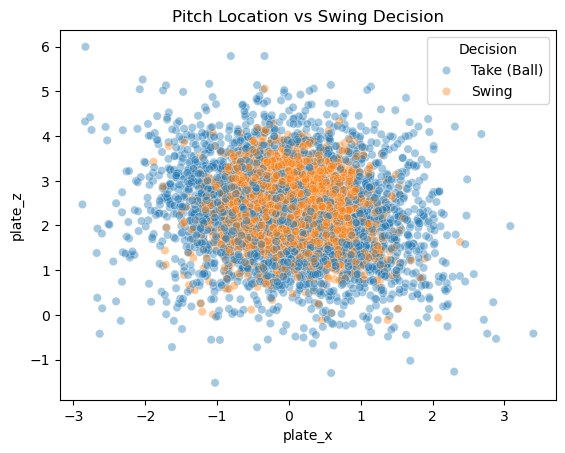

In [58]:
sample["swing_label"] = sample["y_swing"].map({0: "Take (Ball)", 1: "Swing"})

sns.scatterplot(
    data=sample,
    x="plate_x",
    y="plate_z",
    hue="swing_label",
    alpha=0.4
)

plt.title("Pitch Location vs Swing Decision")
plt.legend(title="Decision");

Let's now analyze swing rate at each pitch type. Different pitch types (fastballs, sliders, changeups) are designed to deceive hitters in different ways, so swing behavior should vary across them. This helps us see whether pitch identity is predictive, which informs feature importance for our model.

In [59]:
pitch_swing = june_statcast_2024.groupby("pitch_name")["y_swing"].mean().sort_values(ascending=False)
pitch_swing

pitch_name
4-Seam Fastball    0.495506
Cutter             0.475864
Knuckle Curve      0.470191
Curveball          0.470095
Sweeper            0.468014
Slider             0.462382
Sinker             0.460899
Slurve             0.439560
Knuckleball        0.437037
Changeup           0.410660
Split-Finger       0.408696
Forkball           0.400000
Other              0.387097
Slow Curve         0.307692
Eephus             0.224719
Pitch Out          0.000000
Name: y_swing, dtype: float64

**To analyze this further: Let's put it into a graph!** 

Text(0.5, 0, 'Probability of Swing')

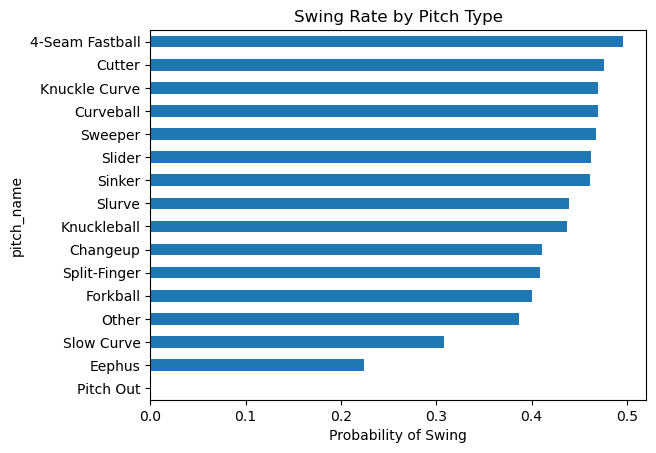

In [61]:
june_statcast_2024.groupby("pitch_name")["y_swing"].mean().sort_values().plot(kind="barh")
plt.title("Swing Rate by Pitch Type")
plt.xlabel("Probability of Swing")

Batters are more likely to swing at faster and more standard pitches like a 4-seam fastball, while slower or more deceptive pitches lead to fewer strings. Even more extreme offspeed pitches such as eephus and slow curves tend to have very low swing rates, showing that deception and timing disruptuon reduce aggrssion.